# Step 1:Load the data in a notebook

## 1a. Load the data in a notebook

In [1]:
import pandas as pd
import numpy as np

cols = ["engine", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

train = pd.read_csv("../data/train_FD001.txt", sep=r"\s+", header=None, names=cols)

print(train.shape)
print(train.head())
print("Number of engines:", train["engine"].nunique())
print(train.groupby("engine")["cycle"].max().describe())

(20631, 26)
   engine  cycle     op1     op2    op3      s1      s2       s3       s4  \
0       1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1       1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2       1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3       1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4       1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  38.95  23.3

# Step 2: Explore the sensors and pick the useful ones

## 2a. Add the RUL (cycles left before failure) column

In [2]:
# RUL = last cycle of that engine - current cycle
max_cycle = train.groupby("engine")["cycle"].transform("max")
train["RUL"] = max_cycle - train["cycle"]

print(train[["engine", "cycle", "RUL"]].head())
print(train[["engine", "cycle", "RUL"]].tail())

   engine  cycle  RUL
0       1      1  191
1       1      2  190
2       1      3  189
3       1      4  188
4       1      5  187
       engine  cycle  RUL
20626     100    196    4
20627     100    197    3
20628     100    198    2
20629     100    199    1
20630     100    200    0


## 2b. Find sensors that never change

In [5]:
sensor_cols = [f"s{i}" for i in range(1, 22)]

stds = train[sensor_cols].std().sort_values()
print(stds)

s19    0.000000e+00
s18    0.000000e+00
s16    1.556432e-14
s10    4.660829e-13
s5     3.394700e-12
s1     6.537152e-11
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64


# 2c. Plot a few sensors for one engine

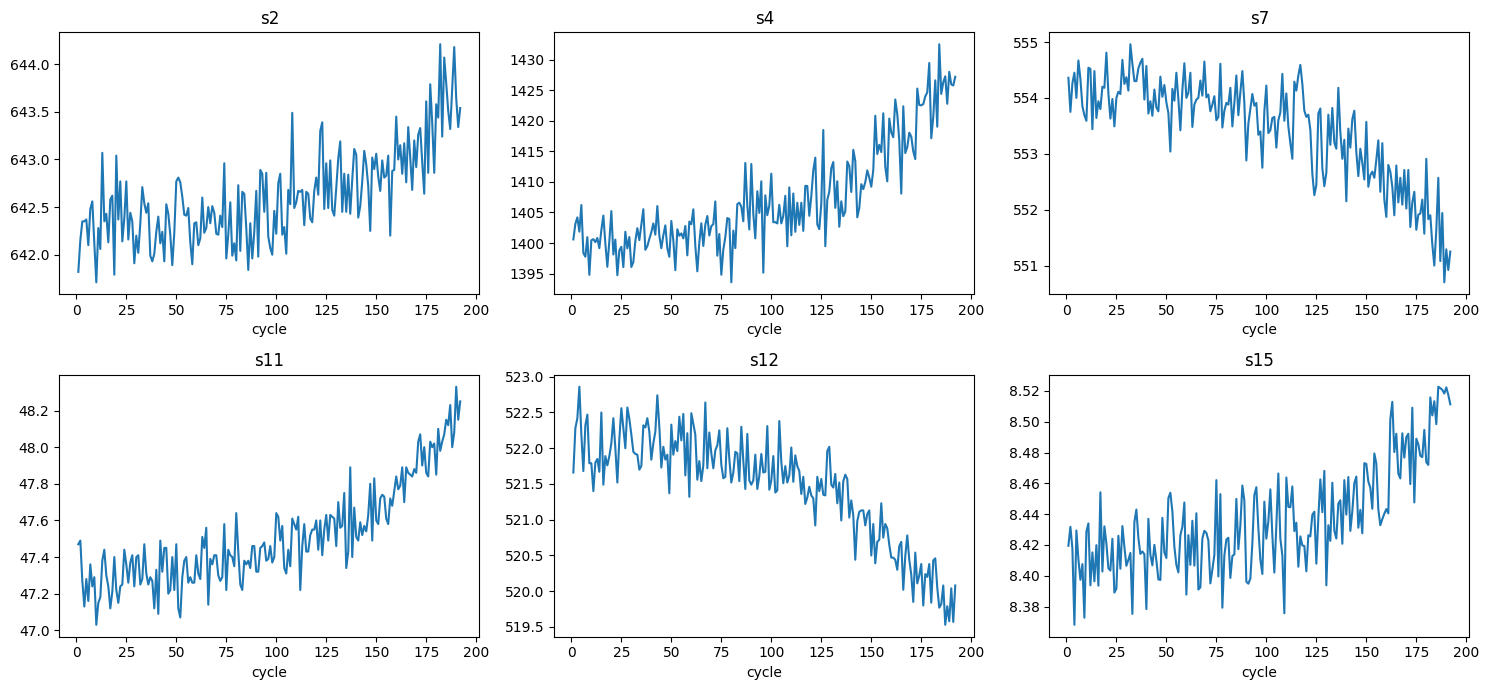

In [7]:
import matplotlib.pyplot as plt

eng = train[train["engine"] == 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, s in zip(axes.ravel(), ["s2", "s4", "s7", "s11", "s12", "s15"]):
    ax.plot(eng["cycle"], eng[s])
    ax.set_title(s)
    ax.set_xlabel("cycle")
plt.tight_layout()
plt.show()

# Step 3: Select sensors and normalize

## 3a. Drop the useless sensors

In [8]:
useful = [s for s in sensor_cols if train[s].std() > 0.01]
print(len(useful), useful)

14 ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## 3b. Normalize

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = train.copy()
train_scaled[useful] = scaler.fit_transform(train[useful])

print(train_scaled[useful].describe().loc[["mean", "std"]].round(2))

       s2   s3   s4   s7   s8   s9  s11  s12  s13  s14  s15  s17  s20  s21
mean  0.0 -0.0  0.0 -0.0  0.0 -0.0 -0.0  0.0  0.0 -0.0  0.0  0.0  0.0  0.0
std   1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


## 3c. See which sensors track degradation best

In [10]:
corr = train_scaled[useful + ["RUL"]].corr()["RUL"].drop("RUL")
print(corr.sort_values())

s11   -0.696228
s4    -0.678948
s15   -0.642667
s2    -0.606484
s17   -0.606154
s3    -0.584520
s8    -0.563968
s13   -0.562569
s9    -0.390102
s14   -0.306769
s20    0.629428
s21    0.635662
s7     0.657223
s12    0.671983
Name: RUL, dtype: float64


# Step 4: Choose final features and build engine sequences

## 4a. Keep the strongest sensors

In [11]:
features = ["s2", "s4", "s7", "s11", "s12", "s15", "s17", "s20", "s21"]
print(len(features), "features selected")

9 features selected


## 4b. Build the input format the HMM expects

In [12]:
X = train_scaled[features].values                       # all rows stacked
lengths = train_scaled.groupby("engine").size().values  # cycles per engine

print("X shape:", X.shape)
print("Number of sequences:", len(lengths))
print("First 5 lengths:", lengths[:5])
print("Sum of lengths == rows?", lengths.sum() == X.shape[0])

X shape: (20631, 9)
Number of sequences: 100
First 5 lengths: [192 287 179 189 269]
Sum of lengths == rows? True


# Step 5: Fit a Gaussian HMM with 4 hidden states

## 5a. Build and train the model

from hmmlearn.hmm import GaussianHMM

n_states = 4

model = GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=200,
    tol=1e-3,
    random_state=42,
    init_params="mc",   # only auto-initialize means and covariances
    params="stmc",      # but still learn everything
    verbose=True,
)

# Left-to-right start: every engine begins healthy
model.startprob_ = np.array([1.0, 0.0, 0.0, 0.0])

# Stay with prob 0.98, move forward with 0.02; last state is absorbing
model.transmat_ = np.array([
    [0.98, 0.02, 0.00, 0.00],
    [0.00, 0.98, 0.02, 0.00],
    [0.00, 0.00, 0.98, 0.02],
    [0.00, 0.00, 0.00, 1.00],
])

model.fit(X, lengths)

## 5b. Inspect what it learned

In [18]:
np.set_printoptions(precision=3, suppress=True)
print("Transition matrix:\n", model.transmat_)
print("\nLog-likelihood:", model.score(X, lengths))

Transition matrix:
 [[0.96  0.04  0.    0.   ]
 [0.    0.984 0.016 0.   ]
 [0.    0.    0.986 0.014]
 [0.    0.    0.    1.   ]]

Log-likelihood: -169114.3239747504


## 5c. Decode one engine and plot its states

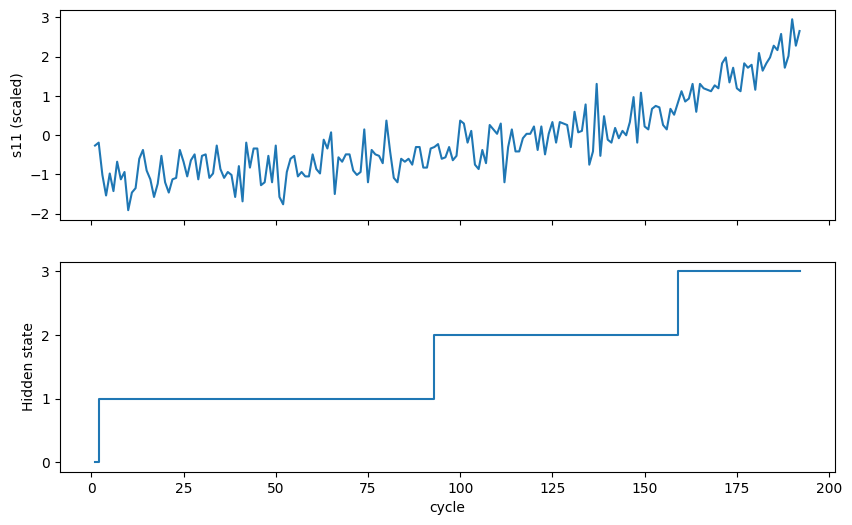

In [19]:
import matplotlib.pyplot as plt

e1 = train_scaled[train_scaled["engine"] == 1]
states = model.predict(e1[features].values)

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(e1["cycle"], e1["s11"])
ax[0].set_ylabel("s11 (scaled)")
ax[1].step(e1["cycle"], states, where="post")
ax[1].set_ylabel("Hidden state")
ax[1].set_yticks(range(n_states))
ax[1].set_xlabel("cycle")
plt.show()

# Step 6: Validate the states and choose the number of states

## 6a. Do the states really match degradation?

In [20]:
states_all = []
for eng_id, g in train_scaled.groupby("engine", sort=True):
    states_all.append(model.predict(g[features].values))

train_scaled["state"] = np.concatenate(states_all)

print(train_scaled.groupby("state")["RUL"].agg(["mean", "min", "max", "count"]).round(1))

        mean  min  max  count
state                        
0      138.4   41  361   2505
1      159.9   40  360   6371
2      103.4   20  277   7188
3       25.2    0   83   4567


## 6b. Pick the best number of states with BIC

In [21]:
def build_lr_hmm(n):
    m = GaussianHMM(n_components=n, covariance_type="diag", n_iter=200,
                    tol=1e-3, random_state=42, init_params="mc", params="stmc")
    start = np.zeros(n); start[0] = 1.0
    trans = np.zeros((n, n))
    for i in range(n - 1):
        trans[i, i], trans[i, i + 1] = 0.98, 0.02
    trans[n - 1, n - 1] = 1.0
    m.startprob_, m.transmat_ = start, trans
    return m

N, d = X.shape
results = []
for n in range(2, 7):
    m = build_lr_hmm(n)
    m.fit(X, lengths)
    logL = m.score(X, lengths)
    k = (n - 1) + 2 * n * d          # free parameters: transitions + means + variances
    bic = k * np.log(N) - 2 * logL
    results.append((n, round(logL), round(bic)))
    print(f"states={n}  logL={logL:.0f}  BIC={bic:.0f}")

states=2  logL=-250875  BIC=502118
states=3  logL=-168795  BIC=338147
states=4  logL=-169114  BIC=338974
states=5  logL=-154256  BIC=309445
states=6  logL=-156286  BIC=313694


# Step 7: Fix the initialization and re-compare

In [22]:
def init_by_life_segments(n, X, lengths):
    seg = []
    for L in lengths:
        frac = np.arange(L) / L
        seg.append(np.minimum((frac * n).astype(int), n - 1))
    seg = np.concatenate(seg)
    means = np.array([X[seg == i].mean(axis=0) for i in range(n)])
    covars = np.array([X[seg == i].var(axis=0) + 1e-3 for i in range(n)])
    return means, covars


def build_lr_hmm_v2(n, X, lengths):
    m = GaussianHMM(n_components=n, covariance_type="diag", n_iter=300,
                    tol=1e-3, random_state=42, init_params="", params="stmc")
    m.means_, m.covars_ = init_by_life_segments(n, X, lengths)

    p = n / lengths.mean()            # expected cycles per state ~ avg life / n
    start = np.zeros(n); start[0] = 1.0
    trans = np.zeros((n, n))
    for i in range(n - 1):
        trans[i, i], trans[i, i + 1] = 1 - p, p
    trans[n - 1, n - 1] = 1.0
    m.startprob_, m.transmat_ = start, trans
    return m


N, d = X.shape
models = {}
for n in range(3, 7):
    m = build_lr_hmm_v2(n, X, lengths)
    m.fit(X, lengths)
    models[n] = m

    logL = m.score(X, lengths)
    k = (n - 1) + 2 * n * d
    bic = k * np.log(N) - 2 * logL
    print(f"\nstates={n}  logL={logL:.0f}  BIC={bic:.0f}")

    st = np.concatenate([m.predict(g[features].values)
                         for _, g in train_scaled.groupby("engine", sort=True)])
    print(train_scaled.assign(st=st).groupby("st")["RUL"].mean().round(1).to_dict())


states=3  logL=-168794  BIC=338144
{0: 160.3, 1: 107.2, 2: 24.9}

states=4  logL=-156806  BIC=314356
{0: 161.7, 1: 126.4, 2: 63.6, 3: 15.9}

states=5  logL=-150075  BIC=301085
{0: 167.2, 1: 134.0, 2: 102.6, 3: 43.0, 4: 11.8}

states=6  logL=-146612  BIC=294347
{0: 167.8, 1: 142.0, 2: 118.3, 3: 68.5, 4: 31.3, 5: 9.4}


# Step 8: Predict Remaining Useful Life on test engines

## 8a. State → RUL lookup

In [23]:
model = models[6]

train_scaled["state"] = np.concatenate(
    [model.predict(g[features].values) for _, g in train_scaled.groupby("engine", sort=True)]
)
state_rul = train_scaled.groupby("state")["RUL"].mean().values
print(state_rul.round(1))

[167.8 142.  118.3  68.5  31.3   9.4]


## 8b. Load and scale the test data

In [24]:
test = pd.read_csv("../data/test_FD001.txt", sep=r"\s+", header=None, names=cols)
true_rul = pd.read_csv("../data/RUL_FD001.txt", header=None)[0].values

test_scaled = test.copy()
test_scaled[useful] = scaler.transform(test[useful])

print(test_scaled["engine"].nunique(), "test engines;", len(true_rul), "true RUL values")

100 test engines; 100 true RUL values


## 8c. Predict and evaluate

RMSE: 35.0 cycles


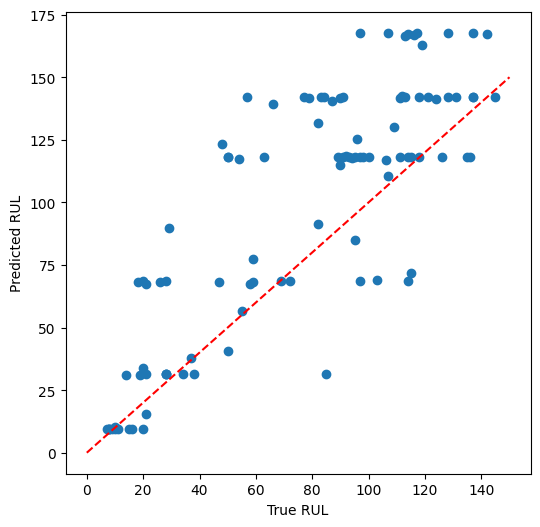

In [25]:
preds = []
for eng_id, g in test_scaled.groupby("engine", sort=True):
    post = model.predict_proba(g[features].values)[-1]   # state probabilities at last cycle
    preds.append(post @ state_rul)
preds = np.array(preds)

rmse = np.sqrt(np.mean((preds - true_rul) ** 2))
print("RMSE:", round(rmse, 1), "cycles")

plt.figure(figsize=(6, 6))
plt.scatter(true_rul, preds)
plt.plot([0, 150], [0, 150], "r--")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.show()

# Step 9: Baseline comparison and the RUL cap

## 9a. Baseline: linear regression

In [26]:
from sklearn.linear_model import LinearRegression

y_clip = train_scaled["RUL"].clip(upper=125)
lr = LinearRegression().fit(train_scaled[features], y_clip)

last_rows = test_scaled.groupby("engine").tail(1)
lr_pred = lr.predict(last_rows[features])

rmse_lr = np.sqrt(np.mean((lr_pred - true_rul) ** 2))
print("Linear regression RMSE:", round(rmse_lr, 1))

Linear regression RMSE: 23.3


## 9b. HMM with the RUL cap

In [27]:
train_scaled["RUL_clip"] = train_scaled["RUL"].clip(upper=125)
state_rul_clip = train_scaled.groupby("state")["RUL_clip"].mean().values
print("State RUL (capped):", state_rul_clip.round(1))

preds_clip = []
for eng_id, g in test_scaled.groupby("engine", sort=True):
    post = model.predict_proba(g[features].values)[-1]
    preds_clip.append(post @ state_rul_clip)
preds_clip = np.array(preds_clip)

rmse_hmm_clip = np.sqrt(np.mean((preds_clip - true_rul) ** 2))
print("HMM RMSE (capped):", round(rmse_hmm_clip, 1))

State RUL (capped): [121.8 108.8 100.5  67.5  31.3   9.4]
HMM RMSE (capped): 23.6


## 9c. Compare visually

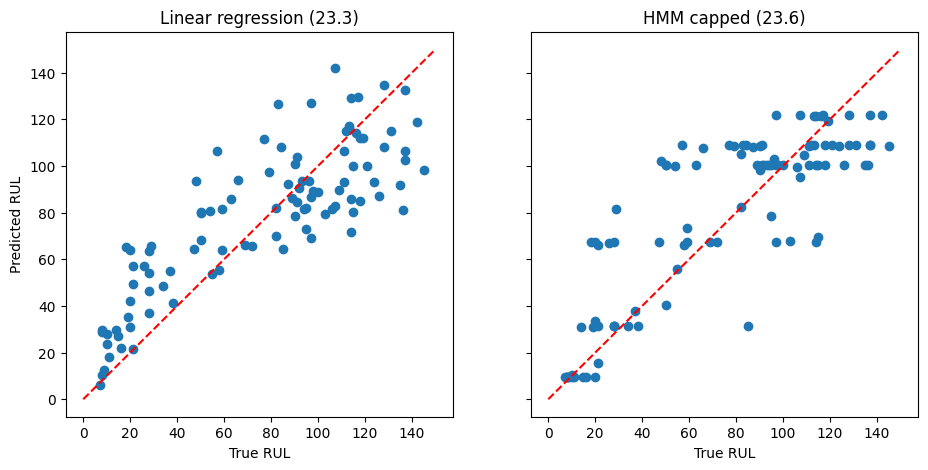

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for a, p, title in zip(ax, [lr_pred, preds_clip],
                       [f"Linear regression ({rmse_lr:.1f})", f"HMM capped ({rmse_hmm_clip:.1f})"]):
    a.scatter(true_rul, p)
    a.plot([0, 150], [0, 150], "r--")
    a.set_title(title)
    a.set_xlabel("True RUL")
ax[0].set_ylabel("Predicted RUL")
plt.show()

# Step 10: Failure warning probability

## 10a. Warning probability for every test engine

In [29]:
from sklearn.metrics import roc_auc_score

warn_prob = []
for eng_id, g in test_scaled.groupby("engine", sort=True):
    post = model.predict_proba(g[features].values)[-1]
    warn_prob.append(post[4] + post[5])
warn_prob = np.array(warn_prob)

near_failure = (true_rul <= 30).astype(int)
print("Engines truly near failure:", near_failure.sum(), "of", len(near_failure))
print("AUC:", round(roc_auc_score(near_failure, warn_prob), 3))

Engines truly near failure: 25 of 100
AUC: 0.966


## 10b. Pick a threshold and check the alert quality

In [30]:
from sklearn.metrics import precision_score, recall_score

for t in [0.3, 0.5, 0.7]:
    alert = (warn_prob >= t).astype(int)
    print(f"threshold={t}  precision={precision_score(near_failure, alert):.2f}  "
          f"recall={recall_score(near_failure, alert):.2f}  alerts={alert.sum()}")

threshold=0.3  precision=0.76  recall=0.76  alerts=25
threshold=0.5  precision=0.79  recall=0.76  alerts=24
threshold=0.7  precision=0.79  recall=0.76  alerts=24


## 10c. Live warning curve for one engine

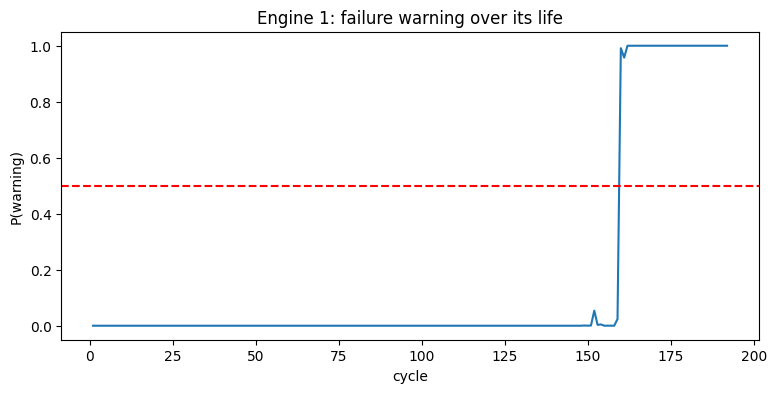

In [31]:
g = train_scaled[train_scaled["engine"] == 1]
Xe = g[features].values

live = []
for t in range(1, len(Xe) + 1):
    post = model.predict_proba(Xe[:t])[-1]
    live.append(post[4] + post[5])

plt.figure(figsize=(9, 4))
plt.plot(g["cycle"], live)
plt.axhline(0.5, color="r", linestyle="--")
plt.xlabel("cycle")
plt.ylabel("P(warning)")
plt.title("Engine 1: failure warning over its life")
plt.show()

# Step 11: Save the model and build the Streamlit app

## 11a. Save everything the app needs (in the notebook)

In [32]:
import os, joblib
os.makedirs("../models", exist_ok=True)

joblib.dump({
    "model": models[6],
    "scaler": scaler,
    "useful": useful,
    "features": features,
    "state_rul": state_rul_clip,
}, "../models/artifacts.joblib")

print("saved")

saved


# Step 12: Implement Forward, Backward and Viterbi from scratch

## 12a. Extract the model parameters

In [34]:
from scipy.special import logsumexp

model = models[6]

means = model.means_
covars = model.covars_
# hmmlearn may return full matrices for "diag"; keep only the variances
var = np.array([np.diag(c) for c in covars]) if covars.ndim == 3 else covars

with np.errstate(divide="ignore"):          # log(0) = -inf is expected (left-to-right)
    logpi = np.log(model.startprob_)
    logA = np.log(model.transmat_)

print(means.shape, var.shape, logA.shape)

(6, 9) (6, 9) (6, 6)


## 12b. Emission log-probabilities

In [35]:
def log_emission(X, means, var):
    T, n = X.shape[0], means.shape[0]
    out = np.zeros((T, n))
    for i in range(n):
        out[:, i] = -0.5 * np.sum(
            np.log(2 * np.pi * var[i]) + (X - means[i]) ** 2 / var[i], axis=1
        )
    return out

## 12c. Forward, backward, filtering, smoothing

In [36]:
def forward(logB, logpi, logA):
    T, n = logB.shape
    la = np.zeros((T, n))
    la[0] = logpi + logB[0]
    for t in range(1, T):
        la[t] = logB[t] + logsumexp(la[t - 1][:, None] + logA, axis=0)
    return la

def backward(logB, logA):
    T, n = logB.shape
    lb = np.zeros((T, n))
    for t in range(T - 2, -1, -1):
        lb[t] = logsumexp(logA + logB[t + 1] + lb[t + 1], axis=1)
    return lb

def normalize_rows(lx):
    return np.exp(lx - logsumexp(lx, axis=1, keepdims=True))

## 12d. Viterbi (MAP state sequence)

In [37]:
def viterbi(logB, logpi, logA):
    T, n = logB.shape
    delta = np.zeros((T, n))
    psi = np.zeros((T, n), dtype=int)
    delta[0] = logpi + logB[0]
    for t in range(1, T):
        scores = delta[t - 1][:, None] + logA
        psi[t] = scores.argmax(axis=0)
        delta[t] = logB[t] + scores.max(axis=0)
    path = np.zeros(T, dtype=int)
    path[-1] = delta[-1].argmax()
    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]
    return path

## 12e. Check against hmmlearn on engine 1

In [38]:
Xe = train_scaled[train_scaled["engine"] == 1][features].values

logB = log_emission(Xe, means, var)
la = forward(logB, logpi, logA)
lb = backward(logB, logA)

filtered = normalize_rows(la)
smoothed = normalize_rows(la + lb)
path = viterbi(logB, logpi, logA)
loglik = logsumexp(la[-1])

print("Log-likelihood  mine:", round(loglik, 3), " hmmlearn:", round(model.score(Xe), 3))
print("Smoothed posteriors match:", np.allclose(smoothed, model.predict_proba(Xe), atol=1e-6))
print("Viterbi path match:", np.array_equal(path, model.predict(Xe)))
print("Filtered at last cycle == smoothed at last cycle:", np.allclose(filtered[-1], smoothed[-1]))

Log-likelihood  mine: -1376.629  hmmlearn: -1376.629
Smoothed posteriors match: True
Viterbi path match: True
Filtered at last cycle == smoothed at last cycle: True
